# Predicción del precio de vivienda en zonas urbanas de México

**Objetivo:**

Desarrollar un modelo de regresión capaz de predecir el valor comparativo de una vivienda en México, utilizando información histórica proporcionada por la Sociedad Hipotecaria Federal (SHF).

**Data:**

Los datos originales se obtienen de la sección de Índices de Precios de la Vivienda de la SHF. A partir de la información trimestral publicada, se descargaron manualmente archivos de cada trimestre entre 2018 y 2025 (T2) y se construyó un data tomando 2,000 registros aleatorios de cada trimestre, uniéndolos en uno solo terminando con un dataset de 60,000 registros.
https://www.gob.mx/shf/documentos/fuente-de-datos-de-indicadores-de-shf?state=published

Provisionalmente....
Ver si se actualizaron los datos gubernamentales a final del 2025, debido a bloqueo de página.

- 60,000 registros (2,000 registros por trimestre).
  
- 7 Columnas:
    >**FECHA\_YT** (Año y trimestre del dato)<br>
    **CLAVE\_ENTIDAD\_FEDERATIVA\_UBICACION\_INMUEBLE** (Clave del Estado)<br>
    **CAT\_TIPO\_INMUEBLE** (Casa, departamento, condominio, etc)<br>
    **CVE\_CLASE\_INMUEBLE** (Economica, semilujo, residencial, etc)<br>
    **VALOR\_COMPARATIVO\_INMUEBLE** (Target)<br>
    **SUPERFICIE\_CONSTRUIDA**<br>
    **SUPERFICIE\_ACCESORIA** (M2 de áreas adicionales: estacionamiento, terraza, patios, etc

Las variables entidad federativa, tipo y clase de inmueble, vienen ya categorizadas, pero en la misma página viene un archivo descriptivo con cada una de las claves utilizadas y su significado.

**Suposiciones de Data:**

- Probablemente existe sesgo y outliers debido a propiedades de lujo o terrenos amplios. 
- Variables predictoras duplicadas o redundantes.

### Obtención de datos

## Análisis de la información

In [9]:
import numpy as np
import pandas as pd 
import seaborn as sns
from scipy import stats
from sklearn.svm import SVR
from scipy.stats import skew
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, boxcox, yeojohnson
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Se realizó una limpieza inicial para corregir variables que venían como texto, en especial CVE_CLASE_INMUEBLE. Se convirtieron a valores numéricos eliminando caracteres no válidos. También se revisaron datos faltantes y se observó que no había ninguno.

In [11]:
# Cargar data
data = pd.read_excel(r"Historial_Trimestre.xlsx")
data['CVE_CLASE_INMUEBLE'] = pd.to_numeric(data['CVE_CLASE_INMUEBLE'].astype(str).str.replace('"', ''),errors='coerce')
data.head()

,FECHA_YT,CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE,CAT_TIPO_INMUEBLE,CVE_CLASE_INMUEBLE,VALOR_COMPARATIVO_INMUEBLE,SUPERFICIE_CONSTRUIDA,SUPERFICIE_ACCESORIA
0,2018T1,26,2,3,264860.00,38.00,0.00
1,2018T1,26,2,4,1301154.10,196.96,26.98
2,2018T1,14,3,4,3003000.00,241.53,18.82
3,2018T1,6,3,3,397380.60,60.00,0.00
4,2018T1,28,2,3,491673.74,83.00,0.00


In [12]:
# Datos faltantes
data.isnull().sum()

FECHA_YT                                       0
CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE    0
CAT_TIPO_INMUEBLE                              0
CVE_CLASE_INMUEBLE                             0
VALOR_COMPARATIVO_INMUEBLE                     0
SUPERFICIE_CONSTRUIDA                          0
SUPERFICIE_ACCESORIA                           0
dtype: int64

In [13]:
# Información del data
data.describe()

,CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE,CAT_TIPO_INMUEBLE,CVE_CLASE_INMUEBLE,VALOR_COMPARATIVO_INMUEBLE,SUPERFICIE_CONSTRUIDA,SUPERFICIE_ACCESORIA
count,60000.000000,60000.000000,60000.000000,6.000000e+04,60000.000000,60000.000000
mean,16.252450,2.735850,3.461733,1.385884e+06,82.623367,4.908214
std,8.148648,0.817977,0.674544,1.644996e+06,52.919634,13.551494
min,1.000000,2.000000,1.000000,1.869887e+05,30.000000,0.000000
25%,10.000000,2.000000,3.000000,5.460000e+05,48.800000,0.000000
50%,15.000000,2.000000,3.000000,8.175852e+05,63.625000,0.000000
75%,23.000000,3.000000,4.000000,1.553738e+06,97.630000,0.820000
max,32.000000,4.000000,7.000000,2.548133e+07,498.520000,198.020000


Después de un análisis numérico descriptivo del data se observó que:

* **CAT_TIPO_INMUEBLE** en su mayoría son 2 (casa habitación).
* **VALOR_COMPARATIVO_INMUEBLE** valor máximo es 25 y el promedio es 1.38 millones, pero la mediana de 817 mil lo que indica distribución sesgada a la derecha.
* **SUPERFICIE_CONSTRUIDA** en su mayoría las construcciones son menores a los 97.6 m2, el promedio está en 82.6 m2 y la mediana en 63.6 m2, lo que quiere decir que también esta sesgada.
* **SUPERFICIE_ACCESORIA** su mediana es 0 por lo que la mayoría de los inmuebles no cuenta con áreas adicionales, el promedio al estar en 4.9 m2, presenta distribución sesgada.
* **CVE_CLASE_INMUEBLE** el promedio está en 3.46 por lo que la mayoría se encuentran entre clase social (3) y media (4).


Para entender la distribución de los datos y detectar relaciones importantes, se generaron histogramas de todas las variables y una matriz de correlación para visualizar qué variables tienen mayor relación con el precio del inmueble.

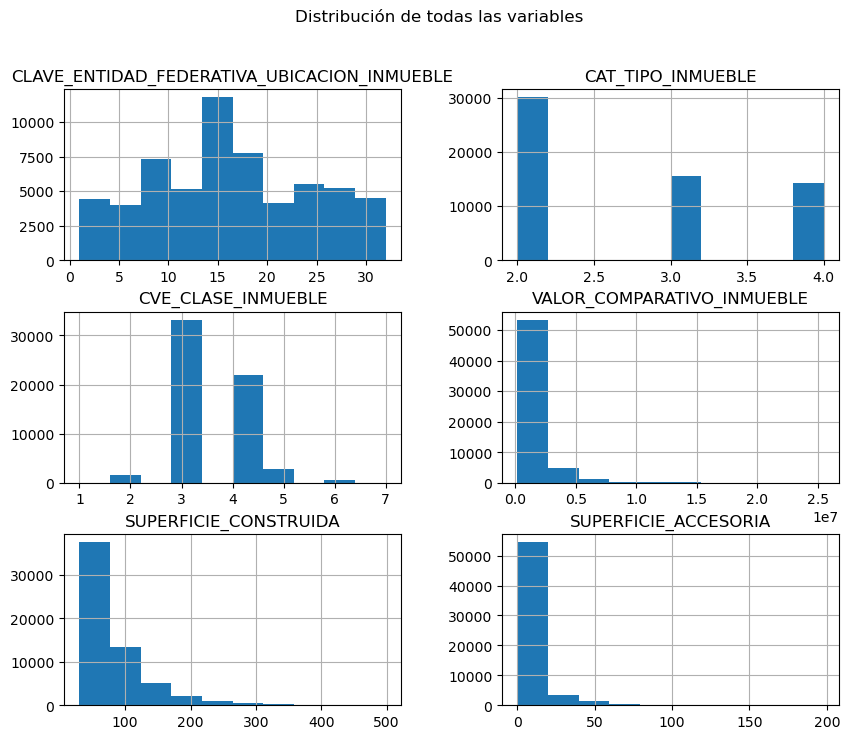

In [16]:
# Histogramas
data.hist(figsize=(10, 8))
plt.suptitle('Distribución de todas las variables')
plt.show()

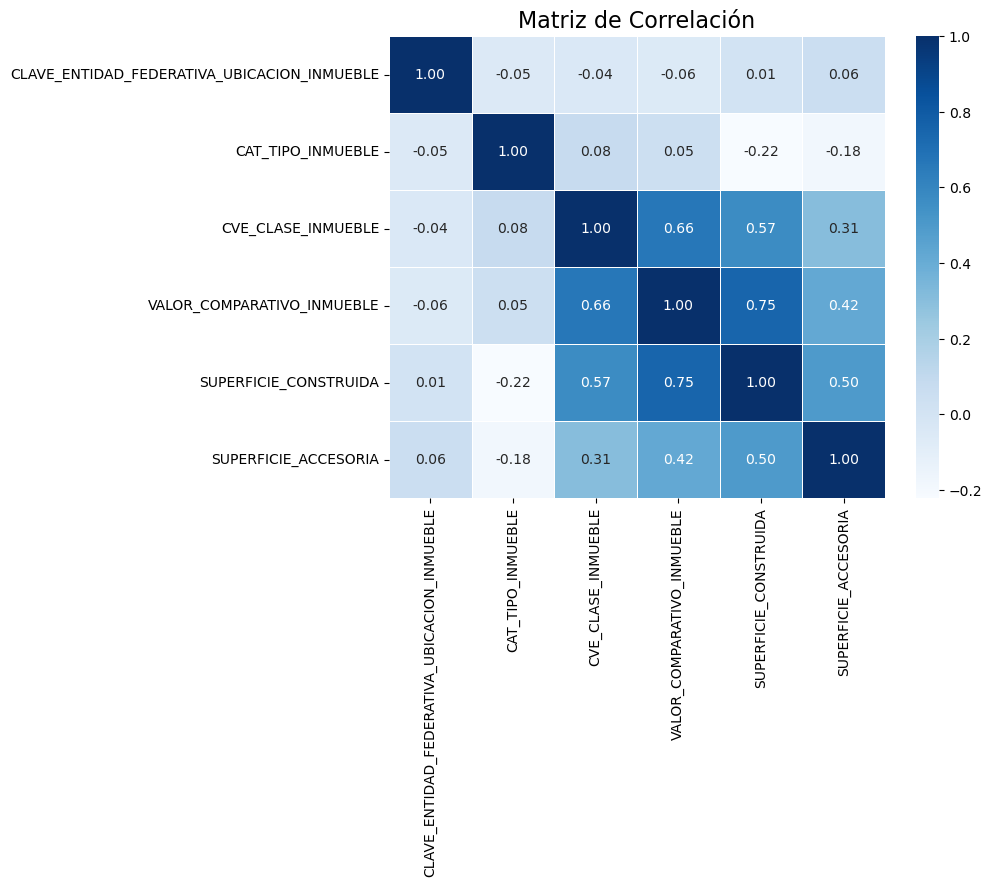

In [17]:
# Matriz de correlación
matriz_corr = data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr,
            annot=True,     
            cmap='Blues',
            fmt=".2f",      
            linewidths=.5)  


plt.title('Matriz de Correlación', fontsize=16)
plt.show()

## Preprocesamiento

**Mapeo de Catálogo**

Como ya se mencionó, de la misma página donde se obtuvo el dataset, se descargó un catálogo con la información de las claves utilizadas (estado, tipo de inmueble y clase de inmueble) para hacer una transformación en sus descripciones textuales utilizando un archivo de diccionario para mejor interpretabilidad del modelo.

In [20]:
# Contiene claves de estados, tipos y clase de inmuebles.
dic = pd.read_excel(r"Descriptor.xlsx")

map_entidad = dic[dic["Variable"] == "CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE"] \
                .set_index("Valor")["Descripción valor"].to_dict()

map_tipo = dic[dic["Variable"] == "CAT_TIPO_INMUEBLE"] \
                .set_index("Valor")["Descripción valor"].to_dict()

map_clase = dic[dic["Variable"] == "CVE_CLASE_INMUEBLE"] \
                .set_index("Valor")["Descripción valor"].to_dict()

data["CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE"] = \
    data["CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE"].map(map_entidad)

data["CAT_TIPO_INMUEBLE"] = data["CAT_TIPO_INMUEBLE"].map(map_tipo)

data["CVE_CLASE_INMUEBLE"] = data["CVE_CLASE_INMUEBLE"].map(map_clase)

**Conversión de ciertas variables**

La variable de Fecha YT cambió su formato y se separó en dos variables diferentes, una con el trimestre y la otra el año.

Además, se creó una variable binaria TIENE_ACCESORIA para indicar si existe o no superficie accesoria.

In [22]:
# Año y trimestre
data['AÑO'] = data['FECHA_YT'].str[0:4].astype(int)
data['TRIMESTRE'] = data['FECHA_YT'].str[-1].astype(int)
data = data.drop(columns="FECHA_YT")

# Binaria de accesoria
data['TIENE_ACCESORIA'] = (data['SUPERFICIE_ACCESORIA'] > 0).astype(int)

**One-hot encoding**

Las variables categóricas mapeadas anteriormente, se convirtieron en variables dummies(0 y 1), eliminando la primera categoría para evitar colinealidad y convirtiendo el dataset totalmente numérico.

In [24]:
# One-hot encoding
data = pd.get_dummies(
    data,
    columns=[
        "CLAVE_ENTIDAD_FEDERATIVA_UBICACION_INMUEBLE",
        "CAT_TIPO_INMUEBLE",
        "CVE_CLASE_INMUEBLE"
    ],
    drop_first=True)

**Análisis exploratorio de outliers**

Se probaron distintos métodos para la detección de outliers pero al final se utilizó el método Modified Z-Score ya que no se ve afectado por la media desplazada y es más robusto ante distribuciones sesgadas.

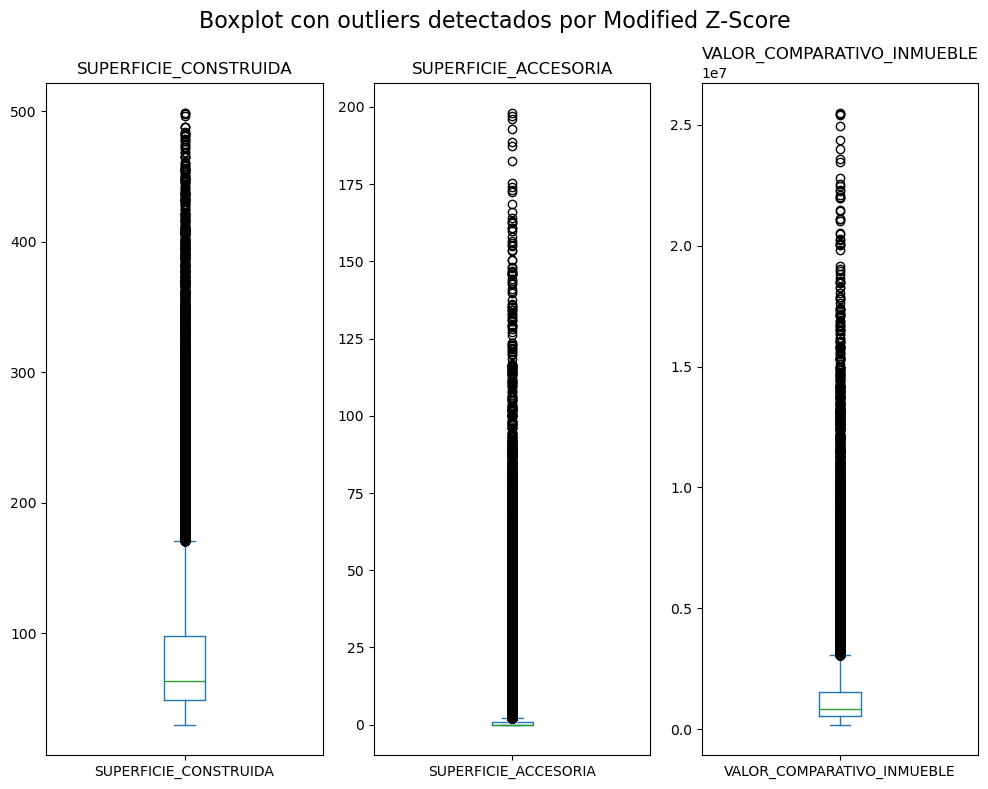


Columna: 'SUPERFICIE_CONSTRUIDA'
Tiene 4764 valores atípicos según Modified Z-Score.

Columna: 'SUPERFICIE_ACCESORIA'
Tiene 15184 valores atípicos según Modified Z-Score.

Columna: 'VALOR_COMPARATIVO_INMUEBLE'
Tiene 6965 valores atípicos según Modified Z-Score.


In [26]:
# Detección de outliers
variables = [
    "SUPERFICIE_CONSTRUIDA",
    "SUPERFICIE_ACCESORIA",
    "VALOR_COMPARATIVO_INMUEBLE"
]

# Modified Z-Score
def detect_outliers_modified_zscore(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / mad
    return np.abs(modified_z) > threshold

# Graficar boxplot
fig, axes = plt.subplots(1, 3, figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]
    data[col].plot(kind='box', ax=ax)
    ax.set_title(col)
    
    # Detectar outliers
    outliers_mask = detect_outliers_modified_zscore(data[col])
    outliers_values = data[col][outliers_mask]

plt.suptitle('Boxplot con outliers detectados por Modified Z-Score', fontsize=16)
plt.tight_layout()
plt.show()

# Número de outliers
for col in variables:
    outliers_mask = detect_outliers_modified_zscore(data[col])
    num_outliers = outliers_mask.sum()
    print(f"\nColumna: '{col}'")
    if num_outliers == 0:
        print("NO tiene valores atípicos según Modified Z-Score.")
    else:
        print(f"Tiene {num_outliers} valores atípicos según Modified Z-Score.")

Como se mencionó en las suposiciones el data presenta una variedad de datos atípicos debido a que las propiedades de lujo o terrenos amplios tienen una gran diferencia comparada a las normales

**Transformaciones**

Calcular el sesgo para decidir la transformación.
* Mayor a 1 -> fuertemente asimétrica (box-cox o log)
* 0.5 a 1 -> moderadamente asimétrica (sqrt o log)
* -0.5 a 0.5 -> casi asimétrica (no necesita)
* -1 a -0.5 -> moderadamente asimétrica (elevar al cuadrado o log)
* Menor a -1 -> cola izquierda (box-cox o log)

In [30]:
# Cálculo del sesgo
for col in variables:
    skewness = skew(data[col].dropna())
    print(f"{col}: sesgo = {skewness:.2f}")

SUPERFICIE_CONSTRUIDA: sesgo = 2.62
SUPERFICIE_ACCESORIA: sesgo = 4.52
VALOR_COMPARATIVO_INMUEBLE: sesgo = 4.63


Se probaron distintos métodos de transformación para saber cuál reduce más el sesgo dependiendo a la variable.

In [32]:
# Prueba de transformaciones
for col in variables:
    
    data_col = data[col].dropna()
    original = skew(data_col) # Sesgo original
    # Log transform (sumamos 1 para evitar log(0))
    log_transformed = skew(np.log1p(data_col))
    # Raíz cuadrada
    sqrt_transformed = skew(np.sqrt(data_col))
    # Box-Cox (requiere valores positivos, sumamos 1 si hay ceros)
    try:
        boxcox_transformed, _ = boxcox(data_col + 1)
        boxcox_skew = skew(boxcox_transformed)
    except ValueError:
        boxcox_skew = np.nan
    
    # Yeo-Johnson 
    yj_transformed, yj_lambda = yeojohnson(data_col)
    yj_skew = skew(yj_transformed)
    
    print(f"\nColumna: {col}")
    print(f"  Original: {original:.2f}")
    print(f"  Log: {log_transformed:.2f}")
    print(f"  Sqrt: {sqrt_transformed:.2f}")
    print(f"  Box-Cox: {boxcox_skew:.2f}")
    print(f"  Yeo-Johnson lambda: {yj_lambda:.2f}")
    print(f"  Yeo-Johnson sesgo: {yj_skew:.2f}")


Columna: SUPERFICIE_CONSTRUIDA
  Original: 2.62
  Log: 0.93
  Sqrt: 1.61
  Box-Cox: 0.12
  Yeo-Johnson lambda: -0.85
  Yeo-Johnson sesgo: 0.12

Columna: SUPERFICIE_ACCESORIA
  Original: 4.52
  Log: 1.67
  Sqrt: 2.19
  Box-Cox: 1.18
  Yeo-Johnson lambda: -1.34
  Yeo-Johnson sesgo: 1.18

Columna: VALOR_COMPARATIVO_INMUEBLE
  Original: 4.63
  Log: 0.89
  Sqrt: 2.16
  Box-Cox: 0.12
  Yeo-Johnson lambda: -0.52
  Yeo-Johnson sesgo: 0.12


Se va a transformar por yeo-Johnson porque es mas flexible, acepta ceros y valores negativos. Reduce el sesgo y mejora la estabilidad de los modelos lineales.

In [34]:
# Transformación Yeo-Johnson
lambdas = {}

for col in variables:
    sesgo_original = data[col].skew()
    data[col], lambdas[col] = yeojohnson(data[col])
    sesgo_transformado = data[col].skew()

    print(f"Columna: {col}")
    print(f"  Yeo-Johnson lambda: {lambdas[col]:.4f}")
    print(f"  Sesgo original: {sesgo_original:.4f}")
    print(f"  Sesgo transformado: {sesgo_transformado:.4f}\n")


Columna: SUPERFICIE_CONSTRUIDA
  Yeo-Johnson lambda: -0.8471
  Sesgo original: 2.6238
  Sesgo transformado: 0.1248

Columna: SUPERFICIE_ACCESORIA
  Yeo-Johnson lambda: -1.3368
  Sesgo original: 4.5157
  Sesgo transformado: 1.1786

Columna: VALOR_COMPARATIVO_INMUEBLE
  Yeo-Johnson lambda: -0.5183
  Sesgo original: 4.6318
  Sesgo transformado: 0.1169



**Selección de variables**

Se realizó una matriz de correlación con el data procesado para observar variables con correlación ≥ 0.5 respecto al target, para identificar posibles predictores importantes y evitar ruido. Pero se decidió no eliminar ninguna debido a que ninguna se mostraba lo suficientemente alta como para eliminarla.

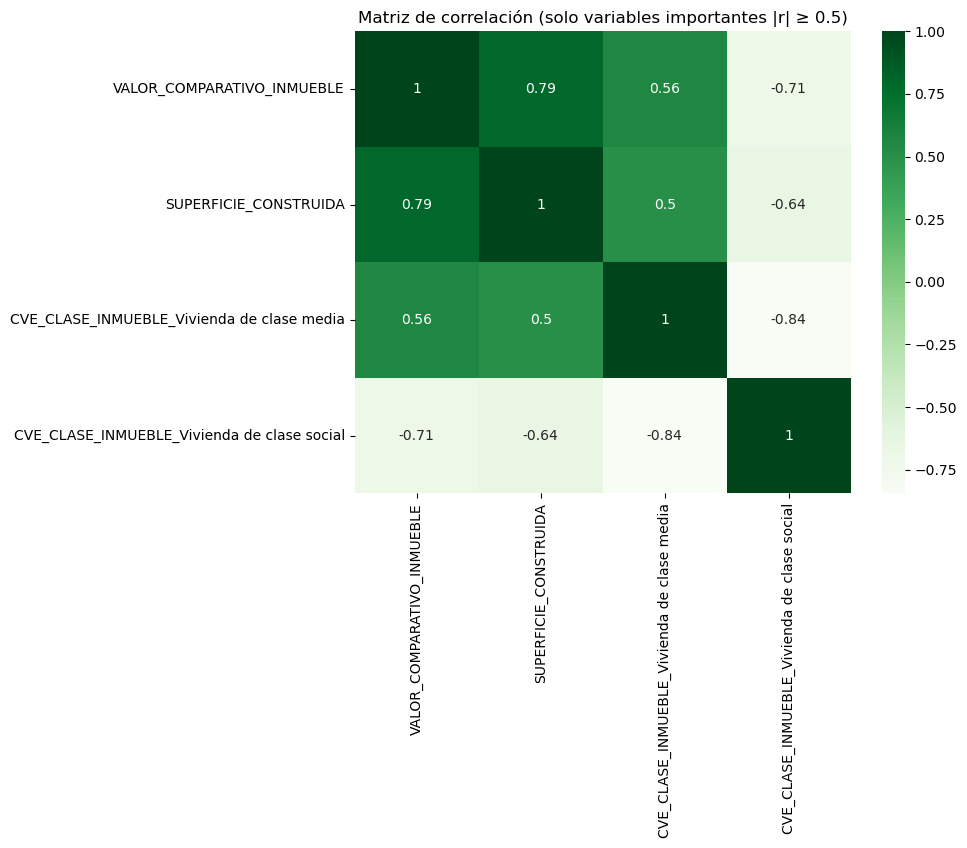

In [36]:
# Matriz de correlación con data procesado
target = "VALOR_COMPARATIVO_INMUEBLE"

corr = data.corr(numeric_only=True)

umbral = 0.5 # correlación
vars_importantes = corr[target].abs()
vars_importantes = vars_importantes[vars_importantes >= umbral].index.tolist()

subset = data[vars_importantes]

corr_subset = subset.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_subset, annot=True, cmap="Greens")
plt.title("Matriz de correlación (solo variables importantes |r| ≥ 0.5)")
plt.show()

## Referencias	

SHF (s. f.). Fuente de datos de indicadores de SHF. gob.mx  
https://www.gob.mx/shf/documentos/fuente-de-datos-de-indicadores-de-shf?state=published